In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_curve, auc

In [2]:
df=pd.read_csv('sepsis.csv')
df

,age,gender,weight_kg,height_cm,bmi,insurance,hr_mean,sbp_mean,dbp_mean,map_mean,...,insulin_infusion_flag,sofa_score,apache_iv,qsofa,sirs_criteria,gcs_total,icu_los_hours,icu_admit_time_hour,readmission_30day,sepsis_label
0,72,M,99.5,160.6,38.6,Medicare,83.0,113.8,65.6,NaN,...,0,12,47.9,2,1,12,27.0,15,1,1
1,62,M,101.2,164.5,37.4,Private,97.5,110.9,64.5,80.0,...,0,12,35.0,1,1,6,21.5,21,0,0
2,74,M,64.0,167.2,22.9,Private,100.6,119.5,65.4,83.4,...,0,8,29.0,1,1,11,46.7,19,0,0
3,87,M,75.1,180.5,23.0,Medicare,95.5,132.5,81.5,98.5,...,0,9,35.6,1,1,7,1.7,8,0,0
4,61,M,52.5,158.4,NaN,Private,86.7,102.0,59.7,73.8,...,1,7,34.6,1,1,8,64.0,9,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,64,M,73.0,177.0,NaN,Private,75.2,71.0,41.0,51.0,...,0,7,31.0,2,0,12,9.1,19,0,0
4996,75,F,62.3,190.0,17.3,Medicare,98.3,113.1,70.3,84.6,...,0,9,41.6,1,1,9,11.2,22,0,0
4997,89,F,74.2,175.7,24.1,Medicare,102.7,145.4,89.3,108.0,...,0,14,75.9,2,2,9,55.2,22,0,1
4998,77,M,64.1,163.7,23.9,Medicare,89.8,139.7,86.1,104.0,...,0,9,29.8,1,0,8,34.4,19,0,0


In [3]:
df.shape

(5000, 62)

In [4]:
df.columns

Index(['age', 'gender', 'weight_kg', 'height_cm', 'bmi', 'insurance',
       'hr_mean', 'sbp_mean', 'dbp_mean', 'map_mean', 'temp_celsius_mean',
       'temp_celsius_max', 'temp_celsius_min', 'temp_celsius_std', 'spo2_mean',
       'spo2_min', 'spo2_max', 'respiratory_rate_mean', 'respiratory_rate_max',
       'respiratory_rate_min', 'wbc', 'lactate_mmol', 'creatinine',
       'platelet_count', 'bilirubin_total', 'glucose', 'ph_arterial',
       'pao2_fio2_ratio', 'inr', 'sodium', 'potassium', 'chloride',
       'bicarbonate', 'hematocrit', 'hemoglobin', 'diabetes', 'hypertension',
       'chf', 'copd', 'chronic_kidney_disease', 'liver_disease',
       'immunosuppression', 'cad', 'atrial_fibrillation', 'cancer_active',
       'vasopressors_flag', 'mechanical_ventilation', 'fio2_percent',
       'antibiotics_24h', 'fluids_ml_24h', 'sedation_score',
       'vasopressor_dose_mcg_kg_min', 'insulin_infusion_flag', 'sofa_score',
       'apache_iv', 'qsofa', 'sirs_criteria', 'gcs_total', 'icu

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 62 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   age                          5000 non-null   int64  
 1   gender                       5000 non-null   object 
 2   weight_kg                    5000 non-null   float64
 3   height_cm                    5000 non-null   float64
 4   bmi                          4749 non-null   float64
 5   insurance                    5000 non-null   object 
 6   hr_mean                      5000 non-null   float64
 7   sbp_mean                     5000 non-null   float64
 8   dbp_mean                     5000 non-null   float64
 9   map_mean                     4837 non-null   float64
 10  temp_celsius_mean            5000 non-null   float64
 11  temp_celsius_max             5000 non-null   float64
 12  temp_celsius_min             5000 non-null   float64
 13  temp_celsius_std  

In [6]:
df.describe()

,age,weight_kg,height_cm,bmi,hr_mean,sbp_mean,dbp_mean,map_mean,temp_celsius_mean,temp_celsius_max,...,insulin_infusion_flag,sofa_score,apache_iv,qsofa,sirs_criteria,gcs_total,icu_los_hours,icu_admit_time_hour,readmission_30day,sepsis_label
count,5000.000000,5000.000000,5000.000000,4749.000000,5000.000000,5000.000000,5000.00000,4837.000000,5000.000000,5000.000000,...,5000.000000,5000.0000,5000.000000,5000.000000,5000.000000,5000.000000,5000.000000,5000.0000,5000.000000,5000.000000
mean,64.271600,74.882440,170.042780,25.835965,90.632460,126.533460,76.42710,93.091896,37.325280,37.769740,...,0.062400,8.3982,36.258860,1.202600,0.952600,9.125000,48.171620,12.8858,0.053800,0.150000
std,14.287136,18.609579,9.498858,5.876215,21.764086,21.087581,14.00437,15.605110,0.773615,0.605078,...,0.241905,1.9435,14.332177,0.487033,0.969815,2.115814,48.757138,6.4812,0.225645,0.357107
min,18.000000,45.000000,150.000000,12.500000,40.000000,49.500000,30.90000,43.900000,30.000000,35.900000,...,0.000000,3.0000,1.300000,0.000000,0.000000,6.000000,1.000000,0.0000,0.000000,0.000000
25%,55.000000,63.500000,163.400000,21.600000,76.975000,112.500000,67.30000,82.800000,36.900000,37.300000,...,0.000000,7.0000,26.700000,1.000000,0.000000,7.000000,13.600000,7.0000,0.000000,0.000000
50%,65.000000,73.700000,170.100000,25.600000,88.300000,126.700000,76.30000,93.100000,37.300000,37.700000,...,0.000000,8.0000,34.500000,1.000000,1.000000,9.000000,33.500000,14.0000,0.000000,0.000000
75%,74.000000,84.400000,176.625000,29.600000,100.500000,141.200000,85.40000,103.900000,37.700000,38.200000,...,0.000000,9.0000,43.525000,1.000000,1.000000,11.000000,66.400000,19.0000,0.000000,0.000000
max,89.000000,241.900000,190.000000,48.400000,239.500000,208.000000,175.50000,153.000000,50.000000,40.000000,...,1.000000,17.0000,101.200000,3.000000,4.000000,15.000000,500.000000,23.0000,1.000000,1.000000


In [7]:
df.head()

,age,gender,weight_kg,height_cm,bmi,insurance,hr_mean,sbp_mean,dbp_mean,map_mean,...,insulin_infusion_flag,sofa_score,apache_iv,qsofa,sirs_criteria,gcs_total,icu_los_hours,icu_admit_time_hour,readmission_30day,sepsis_label
0,72,M,99.5,160.6,38.6,Medicare,83.0,113.8,65.6,NaN,...,0,12,47.9,2,1,12,27.0,15,1,1
1,62,M,101.2,164.5,37.4,Private,97.5,110.9,64.5,80.0,...,0,12,35.0,1,1,6,21.5,21,0,0
2,74,M,64.0,167.2,22.9,Private,100.6,119.5,65.4,83.4,...,0,8,29.0,1,1,11,46.7,19,0,0
3,87,M,75.1,180.5,23.0,Medicare,95.5,132.5,81.5,98.5,...,0,9,35.6,1,1,7,1.7,8,0,0
4,61,M,52.5,158.4,NaN,Private,86.7,102.0,59.7,73.8,...,1,7,34.6,1,1,8,64.0,9,0,0


In [8]:
df.tail()

,age,gender,weight_kg,height_cm,bmi,insurance,hr_mean,sbp_mean,dbp_mean,map_mean,...,insulin_infusion_flag,sofa_score,apache_iv,qsofa,sirs_criteria,gcs_total,icu_los_hours,icu_admit_time_hour,readmission_30day,sepsis_label
4995,64,M,73.0,177.0,NaN,Private,75.2,71.0,41.0,51.0,...,0,7,31.0,2,0,12,9.1,19,0,0
4996,75,F,62.3,190.0,17.3,Medicare,98.3,113.1,70.3,84.6,...,0,9,41.6,1,1,9,11.2,22,0,0
4997,89,F,74.2,175.7,24.1,Medicare,102.7,145.4,89.3,108.0,...,0,14,75.9,2,2,9,55.2,22,0,1
4998,77,M,64.1,163.7,23.9,Medicare,89.8,139.7,86.1,104.0,...,0,9,29.8,1,0,8,34.4,19,0,0
4999,52,F,63.7,173.5,21.2,Private,94.5,136.6,87.4,103.8,...,0,9,30.7,1,1,9,45.7,19,0,0


In [9]:
df.isnull().sum()

age                      0
gender                   0
weight_kg                0
height_cm                0
bmi                    251
                      ... 
gcs_total                0
icu_los_hours            0
icu_admit_time_hour      0
readmission_30day        0
sepsis_label             0
Length: 62, dtype: int64

In [10]:
df.isnull().sum()[df.isnull().sum()>0]

bmi                251
map_mean           163
wbc                527
creatinine         550
platelet_count     550
bilirubin_total    557
glucose            565
ph_arterial        502
inr                558
sodium             531
potassium          504
chloride           497
bicarbonate        511
hematocrit         554
hemoglobin         530
dtype: int64

In [11]:
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    df[col] = df[col].fillna(df[col].median())

In [12]:
df.isnull().sum()[df.isnull().sum()>0]

Series([], dtype: int64)

In [13]:
df.duplicated().sum()

0

In [14]:
df[df.duplicated()]

,age,gender,weight_kg,height_cm,bmi,insurance,hr_mean,sbp_mean,dbp_mean,map_mean,...,insulin_infusion_flag,sofa_score,apache_iv,qsofa,sirs_criteria,gcs_total,icu_los_hours,icu_admit_time_hour,readmission_30day,sepsis_label


In [15]:
df['gender'].unique()

array(['M', 'F', 'Mael'], dtype=object)

In [16]:
df['gender'] = df['gender'].replace({
    'M': 'Male',
    'F': 'Female',
    'Mael': 'Male'
})

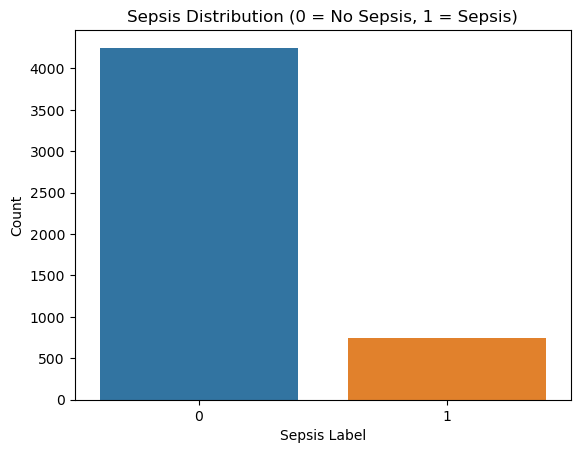

In [17]:
plt.figure()
sns.countplot(x='sepsis_label', data=df)
plt.title("Sepsis Distribution (0 = No Sepsis, 1 = Sepsis)")
plt.xlabel("Sepsis Label")
plt.ylabel("Count")
plt.show()

In [18]:
df['insurance'].value_counts()

insurance
Medicare    1912
Private     1841
Medicaid     869
Self-pay     378
Name: count, dtype: int64

In [19]:
df = pd.get_dummies(df, columns=['insurance','gender'], drop_first=True)

In [20]:
df

,age,weight_kg,height_cm,bmi,hr_mean,sbp_mean,dbp_mean,map_mean,temp_celsius_mean,temp_celsius_max,...,sirs_criteria,gcs_total,icu_los_hours,icu_admit_time_hour,readmission_30day,sepsis_label,insurance_Medicare,insurance_Private,insurance_Self-pay,gender_Male
0,72,99.5,160.6,38.6,83.0,113.8,65.6,93.1,37.0,37.2,...,1,12,27.0,15,1,1,True,False,False,True
1,62,101.2,164.5,37.4,97.5,110.9,64.5,80.0,37.6,38.2,...,1,6,21.5,21,0,0,False,True,False,True
2,74,64.0,167.2,22.9,100.6,119.5,65.4,83.4,37.0,37.8,...,1,11,46.7,19,0,0,False,True,False,True
3,87,75.1,180.5,23.0,95.5,132.5,81.5,98.5,37.5,38.1,...,1,7,1.7,8,0,0,True,False,False,True
4,61,52.5,158.4,25.6,86.7,102.0,59.7,73.8,37.2,37.5,...,1,8,64.0,9,0,0,False,True,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,64,73.0,177.0,25.6,75.2,71.0,41.0,51.0,36.7,37.5,...,0,12,9.1,19,0,0,False,True,False,True
4996,75,62.3,190.0,17.3,98.3,113.1,70.3,84.6,37.9,38.7,...,1,9,11.2,22,0,0,True,False,False,False
4997,89,74.2,175.7,24.1,102.7,145.4,89.3,108.0,37.3,37.9,...,2,9,55.2,22,0,1,True,False,False,False
4998,77,64.1,163.7,23.9,89.8,139.7,86.1,104.0,36.6,36.9,...,0,8,34.4,19,0,0,True,False,False,True


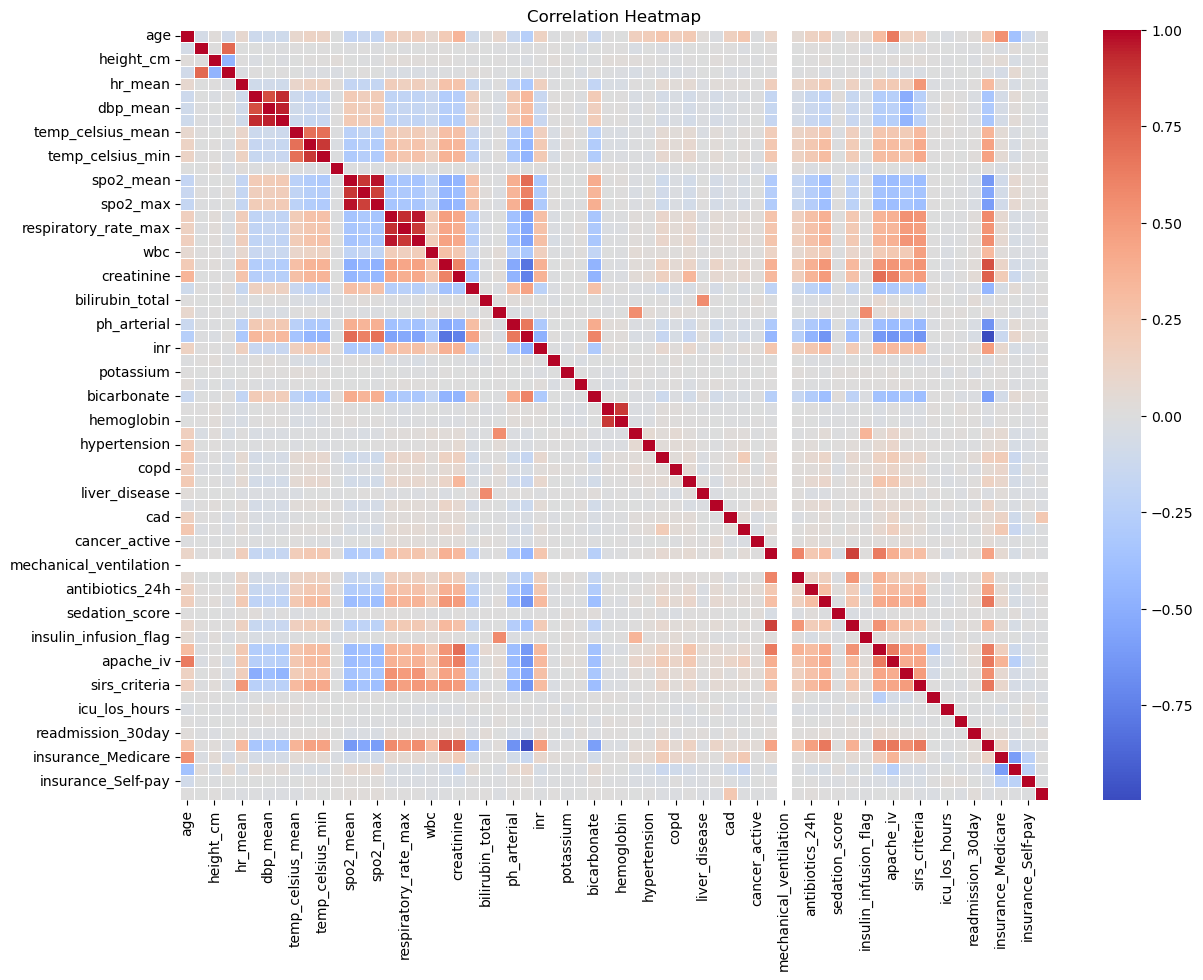

In [21]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(), 
            cmap="coolwarm", 
            annot=False, # avoid clutter
            linewidths=0.5)
plt.title("Correlation Heatmap")
plt.show()

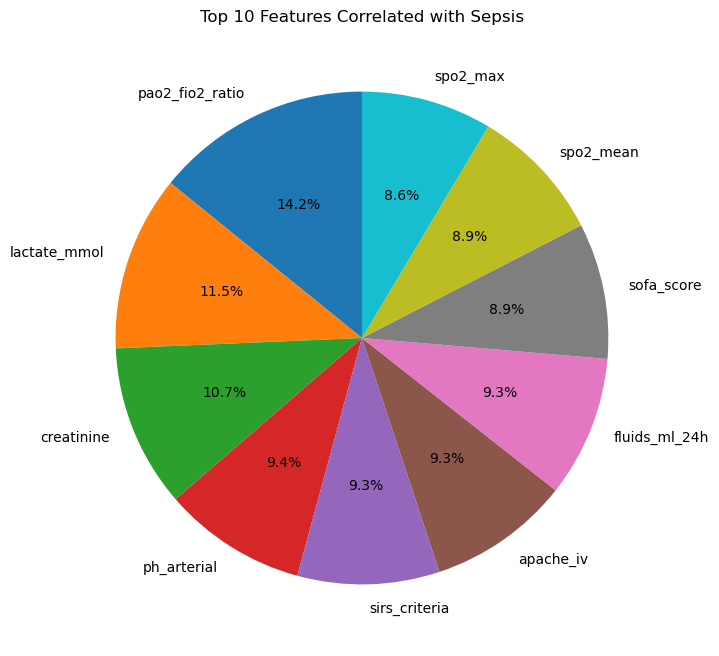

In [22]:
# Top Correlated Features
corr = df.corr()['sepsis_label'].abs().sort_values(ascending=False)
top_features = corr[1:11]
plt.figure(figsize=(8,8))
plt.pie(top_features, 
        labels=top_features.index, 
        autopct='%1.1f%%', 
        startangle=90)
plt.title("Top 10 Features Correlated with Sepsis")
plt.show()

In [23]:
cols_to_drop = [
    # leakage
    'sofa_score', 'apache_iv', 'qsofa', 'sirs_criteria','pao2_fio2_ratio',
    'lactate_mmol', 'creatinine', 'ph_arterial','gcs_total'
    
    # treatment
    'vasopressors_flag', 'mechanical_ventilation',
    'vasopressor_dose_mcg_kg_min', 'antibiotics_24h',
    'insulin_infusion_flag', 'fluids_ml_24h', 'sedation_score',
    
    # time/future
    'icu_los_hours', 'icu_admit_time_hour', 'readmission_30day',
]

In [24]:
df.drop(cols_to_drop, axis=1, inplace=True,errors='ignore')

In [25]:
df.columns

Index(['age', 'weight_kg', 'height_cm', 'bmi', 'hr_mean', 'sbp_mean',
       'dbp_mean', 'map_mean', 'temp_celsius_mean', 'temp_celsius_max',
       'temp_celsius_min', 'temp_celsius_std', 'spo2_mean', 'spo2_min',
       'spo2_max', 'respiratory_rate_mean', 'respiratory_rate_max',
       'respiratory_rate_min', 'wbc', 'platelet_count', 'bilirubin_total',
       'glucose', 'inr', 'sodium', 'potassium', 'chloride', 'bicarbonate',
       'hematocrit', 'hemoglobin', 'diabetes', 'hypertension', 'chf', 'copd',
       'chronic_kidney_disease', 'liver_disease', 'immunosuppression', 'cad',
       'atrial_fibrillation', 'cancer_active', 'vasopressors_flag',
       'fio2_percent', 'gcs_total', 'sepsis_label', 'insurance_Medicare',
       'insurance_Private', 'insurance_Self-pay', 'gender_Male'],
      dtype='object')

In [28]:
# 4. SPLIT FEATURES & TARGET
# split features and target
X = df.drop('sepsis_label', axis=1)
y = df['sepsis_label']

# train test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [29]:
# 5. FEATURE SCALING
# =====================================================

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [30]:
# DEFINE ALL ALGORITHMS
# =====================================================
models = {

    "Logistic Regression": Pipeline([
        ("scaler", StandardScaler()),
        ("model", LogisticRegression(max_iter=1000))
    ]),

    "SVM": Pipeline([
        ("scaler", StandardScaler()),
        ("model", SVC(probability=True))
    ]),

    "Decision Tree": Pipeline([
        ("model", DecisionTreeClassifier())
    ]),

    "Random Forest": Pipeline([
        ("model", RandomForestClassifier())
    ]),

    "AdaBoost": Pipeline([
        ("model", AdaBoostClassifier())
    ]),

    "Gradient Boosting": Pipeline([
        ("model", GradientBoostingClassifier())
    ]),

    "Naive Bayes": Pipeline([
        ("model", GaussianNB())
    ])
}

In [31]:
# 6. TRAIN ALL MODELS
# =====================================================
results = []

for name, model in models.items():
    
    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    cv_score = cross_val_score(model, X_train, y_train, cv=5).mean()

    results.append([name, accuracy, cv_score])


results_df = pd.DataFrame(
    results,
    columns=["Model", "Test Accuracy", "CV Score"]
)

print("\n================ MODEL COMPARISON ================\n")
print(results_df)


================ MODEL COMPARISON ================

                 Model  Test Accuracy  CV Score
0  Logistic Regression          0.992   0.98925
1                  SVM          0.993   0.98900
2        Decision Tree          0.984   0.97050
3        Random Forest          0.994   0.98900
4             AdaBoost          0.996   0.98925
5    Gradient Boosting          0.994   0.98900
6          Naive Bayes          0.985   0.98475


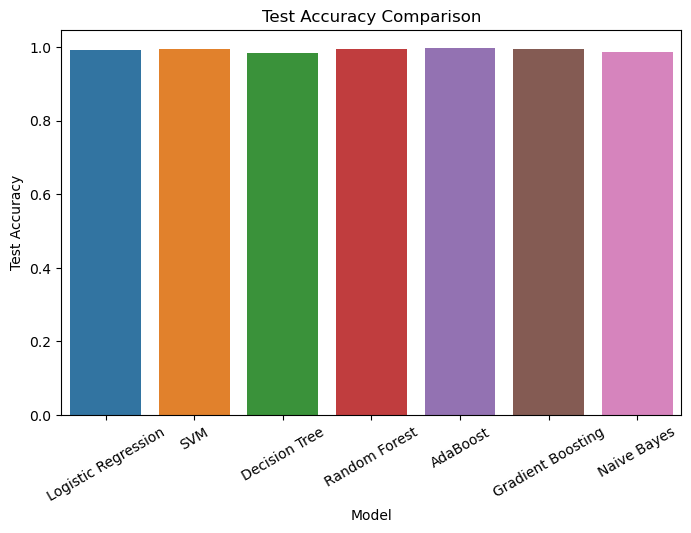

In [32]:
plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="Test Accuracy", data=results_df)
plt.title("Test Accuracy Comparison")
plt.xticks(rotation=30)
plt.show()

In [33]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, AdaBoostClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import accuracy_score
import pandas as pd

tuned_results = []
best_models = {}

# ---------------- Random Forest ----------------
rf = RandomForestClassifier(random_state=42)

rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [5, 10, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

grid_rf = GridSearchCV(rf, rf_params, cv=5, scoring='accuracy', n_jobs=-1)
grid_rf.fit(X_train, y_train)

best_rf = grid_rf.best_estimator_
rf_pred = best_rf.predict(X_test)

tuned_results.append([
    "Random Forest",
    accuracy_score(y_test, rf_pred),
    grid_rf.best_score_,
    grid_rf.best_params_
])

best_models["Random Forest"] = best_rf


# ---------------- Gradient Boosting ----------------
gb = GradientBoostingClassifier(random_state=42)

gb_params = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.1],
    'max_depth': [3, 5],
    'min_samples_split': [2, 5]
}

grid_gb = GridSearchCV(gb, gb_params, cv=5, scoring='accuracy', n_jobs=-1)
grid_gb.fit(X_train, y_train)

best_gb = grid_gb.best_estimator_
gb_pred = best_gb.predict(X_test)

tuned_results.append([
    "Gradient Boosting",
    accuracy_score(y_test, gb_pred),
    grid_gb.best_score_,
    grid_gb.best_params_
])

best_models["Gradient Boosting"] = best_gb


# ---------------- AdaBoost ----------------
ab = AdaBoostClassifier(random_state=42)

ab_params = {
    'n_estimators': [50, 100, 200],
    'learning_rate': [0.01, 0.1, 1]
}

grid_ab = GridSearchCV(ab, ab_params, cv=5, scoring='accuracy', n_jobs=-1)
grid_ab.fit(X_train, y_train)

best_ab = grid_ab.best_estimator_
ab_pred = best_ab.predict(X_test)

tuned_results.append([
    "AdaBoost",
    accuracy_score(y_test, ab_pred),
    grid_ab.best_score_,
    grid_ab.best_params_
])

best_models["AdaBoost"] = best_ab


# ---------------- Final Comparison ----------------
tuned_df = pd.DataFrame(
    tuned_results,
    columns=["Model", "Test Accuracy", "Best CV Score", "Best Parameters"]
)

print("\n=========== TUNED MODEL COMPARISON ===========\n")
print(tuned_df.sort_values(by="Test Accuracy", ascending=False))


=========== TUNED MODEL COMPARISON ===========

               Model  Test Accuracy  Best CV Score  \
0      Random Forest          0.995        0.98900   
1  Gradient Boosting          0.995        0.99025   
2           AdaBoost          0.995        0.99000   

                                     Best Parameters  
0  {'max_depth': None, 'min_samples_leaf': 1, 'mi...  
1  {'learning_rate': 0.1, 'max_depth': 3, 'min_sa...  
2          {'learning_rate': 1, 'n_estimators': 100}  


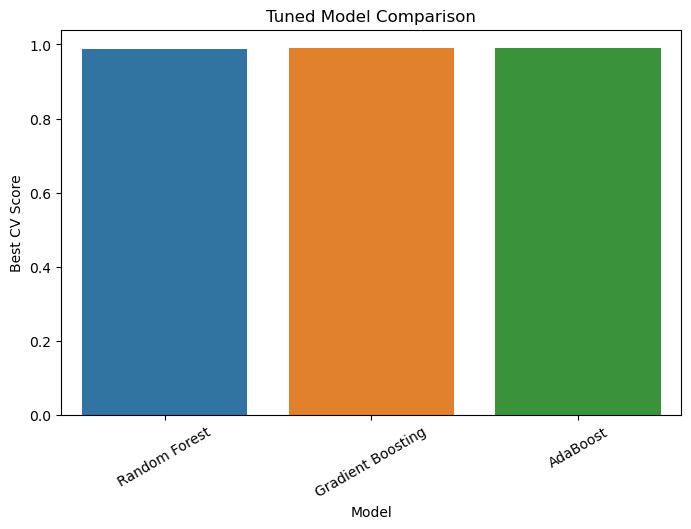

In [34]:
plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="Best CV Score", data=tuned_df)
plt.title("Tuned Model Comparison")
plt.xticks(rotation=30)
plt.show()

In [35]:
# 7. SELECT BEST MODEL
# =====================================================

best_name = results_df.iloc[0]["Model"]   # Model with highest Test Accuracy
best_model = models[best_name]            # Get the model object

print("\nBest Model Selected:", best_name)


Best Model Selected: Logistic Regression


In [36]:
# 8. FINAL EVALUATION
# =====================================================

from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

# Predict on Test Set
y_pred = best_model.predict(X_test)

# Accuracy
train_acc = accuracy_score(y_train, best_model.predict(X_train))
test_acc  = accuracy_score(y_test, y_pred)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test Accuracy:  {test_acc:.4f}")

# Confusion Matrix
print("\n================ CONFUSION MATRIX ================\n")
print(confusion_matrix(y_test, y_pred))

# Classification Report
print("\n================ CLASSIFICATION REPORT ================\n")
print(classification_report(y_test, y_pred))

Train Accuracy: 0.9938
Test Accuracy:  0.9920

================ CONFUSION MATRIX ================

[[845   5]
 [  3 147]]

================ CLASSIFICATION REPORT ================

              precision    recall  f1-score   support

           0       1.00      0.99      1.00       850
           1       0.97      0.98      0.97       150

    accuracy                           0.99      1000
   macro avg       0.98      0.99      0.98      1000
weighted avg       0.99      0.99      0.99      1000



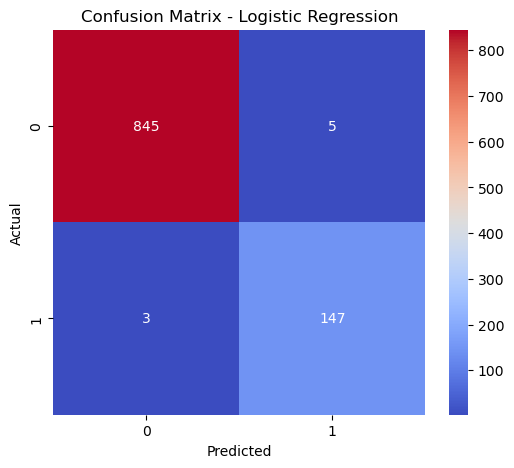

In [37]:
# Compute Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap="coolwarm")
plt.title(f"Confusion Matrix - {best_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

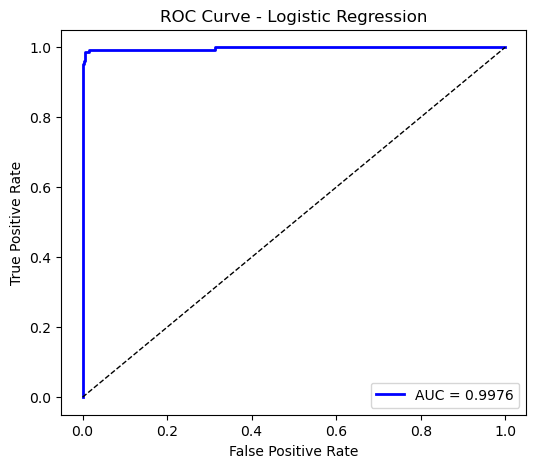

In [38]:
from sklearn.metrics import *
if hasattr(best_model, "predict_proba"):
    y_prob = best_model.predict_proba(X_test)[:, 1]  # Probability for positive class
else:
    y_prob = best_model.decision_function(X_test)    # For models like SVM

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

# Plot ROC curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"AUC = {auc_score:.4f}", color='blue', linewidth=2)
plt.plot([0,1], [0,1], 'k--', linewidth=1)  # Diagonal line
plt.title(f"ROC Curve - {best_name}")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend(loc="lower right")
plt.show()

In [39]:
import joblib
joblib.dump(best_model, "sepsis_model.pkl")
joblib.dump(scaler, "scaler.pkl")
print("Saved successfully")

Saved successfully


In [40]:
import joblib

# remove target
X = df.drop("sepsis_label", axis=1)

# save columns
joblib.dump(X.columns, "columns.pkl")

print("Columns saved")

Columns saved


In [41]:
import os
print(os.getcwd())

C:\Users\91938\PEMPROJECT
